<a href="https://colab.research.google.com/github/soulqan/PCVK_GANJIL_2025/blob/main/Week10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# D. Tugas Praktikum

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Dilasi

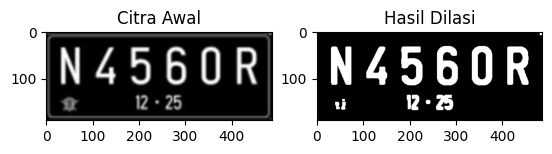

In [3]:
def dilasi_citra(F, w):
    p, q = F.shape
    imgD = np.zeros((p,q), dtype=np.uint8)
    SED = np.ones((w,w), dtype=np.uint8)
    c = (w-1)//2
    for i in range(c, p-c):
        for j in range(c, q-c):
            temp = F[i-c:i+c+1, j-c:j+c+1]
            product = temp*SED
            imgD[i,j] = np.max(product)
    return imgD

img_d = cv2.imread('/content/drive/MyDrive/images/platNomor.png',0)
ret, thresh = cv2.threshold(img_d,125,200,cv2.THRESH_BINARY)
w = 5
imgD = dilasi_citra(thresh,w)

plt.subplot(121),plt.imshow(img_d,cmap='gray'),plt.title('Citra Awal')
plt.subplot(122),plt.imshow(imgD,cmap='gray'),plt.title('Hasil Dilasi')
plt.show()


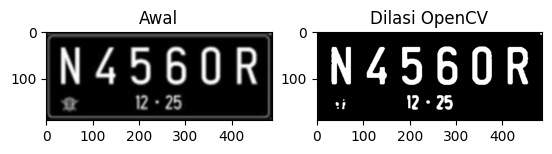

In [5]:
img = cv2.imread('/content/drive/MyDrive/images/platNomor.png',0)
ret, thresh = cv2.threshold(img,127,225,cv2.THRESH_BINARY)
kernel = np.ones((3,3),np.uint8)
dilasi = cv2.dilate(thresh,kernel,iterations=1)

plt.subplot(121),plt.imshow(img,cmap='gray'),plt.title('Awal')
plt.subplot(122),plt.imshow(dilasi,cmap='gray'),plt.title('Dilasi OpenCV')
plt.show()


# Erosi

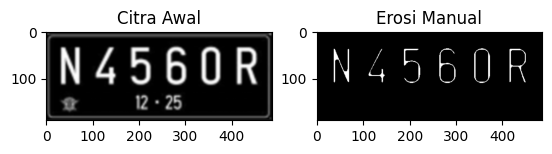

In [7]:
def erosi_citra(F, k):
    m,n = F.shape
    SE = np.ones((k,k),dtype=np.uint8)
    c = (k-1)//2
    imgE = np.zeros((m,n),dtype=np.uint8)
    for i in range(c, m-c):
        for j in range(c, n-c):
            temp = F[i-c:i+c+1, j-c:j+c+1]
            product = temp*SE
            imgE[i,j] = np.min(product)
    return imgE

img_e = cv2.imread('/content/drive/MyDrive/images/platNomor.png',0)
ret,thresh1 = cv2.threshold(img_e,175,225,cv2.THRESH_BINARY)
imgE = erosi_citra(thresh1,5)

plt.subplot(121),plt.imshow(img_e,cmap='gray'),plt.title('Citra Awal')
plt.subplot(122),plt.imshow(imgE,cmap='gray'),plt.title('Erosi Manual')
plt.show()


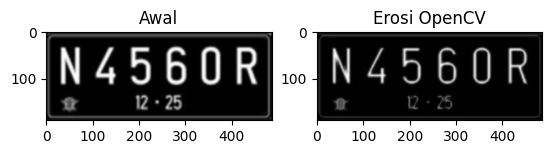

In [8]:
img = cv2.imread('/content/drive/MyDrive/images/platNomor.png',0)
kernel = np.ones((5,5),np.uint8)
erosion = cv2.erode(img,kernel,iterations=1)
plt.subplot(121),plt.imshow(img,cmap='gray'),plt.title('Awal')
plt.subplot(122),plt.imshow(erosion,cmap='gray'),plt.title('Erosi OpenCV')
plt.show()


# Opening

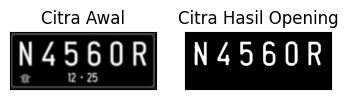

In [13]:
img_o = cv2.imread('/content/drive/MyDrive/images/platNomor.png',0)
retO, thresho = cv2.threshold(img_o, 127, 225, cv2.THRESH_BINARY)
k = 7
imgO = dilasi_citra(erosi_citra(thresho, k), k)

plt.subplot(131), plt.imshow(img_o, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])
plt.subplot(132), plt.imshow(imgO, cmap='gray')
plt.title('Citra Hasil Opening'), plt.xticks([]), plt.yticks([])
plt.show()


Opening tanpa dan dengan library

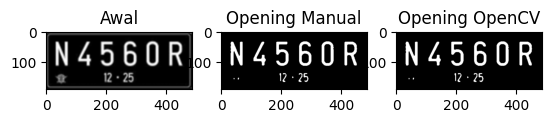

In [14]:
img_c = cv2.imread('/content/drive/MyDrive/images/platNomor.png',0)
ret,th = cv2.threshold(img_o,127,225,cv2.THRESH_BINARY)
k=3
# tanpa library
open_manual = dilasi_citra(erosi_citra(th,k),k)
# dengan OpenCV
kernel = np.ones((3,3),np.uint8)
open_cv = cv2.morphologyEx(th,cv2.MORPH_OPEN,kernel)

plt.subplot(131),plt.imshow(img_o,cmap='gray'),plt.title('Awal')
plt.subplot(132),plt.imshow(open_manual,cmap='gray'),plt.title('Opening Manual')
plt.subplot(133),plt.imshow(open_cv,cmap='gray'),plt.title('Opening OpenCV')
plt.show()

# closing

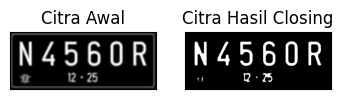

In [15]:
img_c= cv2.imread('/content/drive/MyDrive/images/platNomor.png',0)
retc, threshc = cv2.threshold(img_c, 127, 225,
cv2.THRESH_BINARY)
k=7
imgC = erosi_citra(dilasi_citra(threshc,k),k)
plt.subplot(131),plt.imshow(img_c,cmap = 'gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])
plt.subplot(132),plt.imshow(imgC,cmap = 'gray')
plt.title('Citra Hasil Closing'), plt.xticks([]),
plt.yticks([])
plt.show()

Closing tanpa dan dengan library

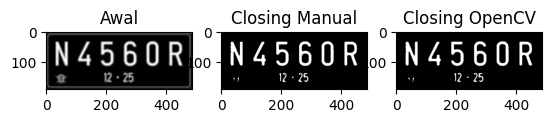

In [16]:
img_o = cv2.imread('/content/drive/MyDrive/images/platNomor.png',0)
ret,th = cv2.threshold(img_c,127,225,cv2.THRESH_BINARY)
k=3
close_manual = erosi_citra(dilasi_citra(th,k),k)
kernel = np.ones((3,3),np.uint8)
close_cv = cv2.morphologyEx(th,cv2.MORPH_CLOSE,kernel)

plt.subplot(131),plt.imshow(img_c,cmap='gray'),plt.title('Awal')
plt.subplot(132),plt.imshow(close_manual,cmap='gray'),plt.title('Closing Manual')
plt.subplot(133),plt.imshow(close_cv,cmap='gray'),plt.title('Closing OpenCV')
plt.show()

# Dilasi Cross 3 × 3 dan 5 × 5

SED Cross 3x3


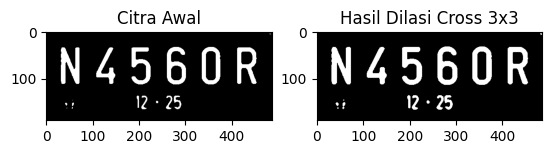

SED Cross 5x5


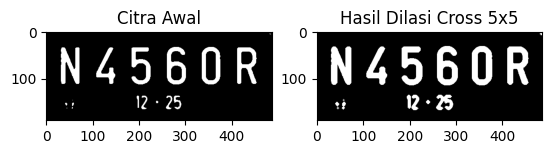

In [24]:
# Modifikasi fungsi dilasi untuk SE Cross
def dilasi_cross(F, w):
    p, q = F.shape
    imgD = np.zeros((p, q), dtype=np.uint8)
    if w == 3:
        SED = np.array([[0, 1, 0], [1, 1, 1], [0, 1, 0]], dtype=np.uint8)
    elif w == 5:
        SED = np.array([[0, 0, 1, 0, 0], [0, 0, 1, 0, 0], [1, 1, 1, 1, 1], [0, 0, 1, 0, 0], [0, 0, 1, 0, 0]], dtype=np.uint8)
    else: # Default ke square jika ukuran lain
        SED = np.ones((w,w), dtype=np.uint8)
    constant = (w - 1) // 2
    for i in range(constant, p - constant):
        for j in range(constant, q - constant):
            temp = F[i - constant:i + constant + 1, j - constant:j + constant + 1]
            product = temp * SED
            imgD[i, j] = np.max(product)
    return imgD

img_d = cv2.imread('/content/drive/MyDrive/images/platNomor.png', 0)
ret, thresh = cv2.threshold(img_d, 127, 225, cv2.THRESH_BINARY)

# Cross 3x3
print('SED Cross 3x3')
imgD3 = dilasi_cross(thresh, 3)
plt.subplot(121), plt.imshow(thresh, cmap='gray'), plt.title('Citra Awal')
plt.subplot(122), plt.imshow(imgD3, cmap='gray'), plt.title('Hasil Dilasi Cross 3x3')
plt.show()

# Cross 5x5
print('SED Cross 5x5')
imgD5 = dilasi_cross(thresh, 5)
plt.subplot(121), plt.imshow(thresh, cmap='gray'), plt.title('Citra Awal')
plt.subplot(122), plt.imshow(imgD5, cmap='gray'), plt.title('Hasil Dilasi Cross 5x5')
plt.show()

# Dilasi Circular 3 × 3 dan 5 × 5

SED Circular 3x3


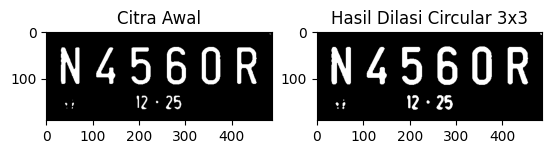

SED Circular 5x5


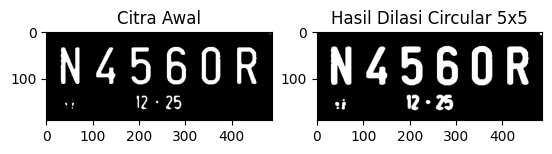

In [23]:
# Modifikasi fungsi dilasi untuk SE Circular
def dilasi_circular(F, w):
    p, q = F.shape
    imgD = np.zeros((p, q), dtype=np.uint8)
    SED = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (w, w))
    constant = (w - 1) // 2
    for i in range(constant, p - constant):
        for j in range(constant, q - constant):
            temp = F[i - constant:i + constant + 1, j - constant:j + constant + 1]
            product = temp * SED
            imgD[i, j] = np.max(product)
    return imgD

img_d = cv2.imread('/content/drive/MyDrive/images/platNomor.png', 0)
ret, thresh = cv2.threshold(img_d, 127, 225, cv2.THRESH_BINARY)

# Circular 3x3
print('SED Circular 3x3')
imgD3_circ = dilasi_circular(thresh, 3)
plt.subplot(121), plt.imshow(thresh, cmap='gray'), plt.title('Citra Awal')
plt.subplot(122), plt.imshow(imgD3_circ, cmap='gray'), plt.title('Hasil Dilasi Circular 3x3')
plt.show()

# Circular 5x5
print('SED Circular 5x5')
imgD5_circ = dilasi_circular(thresh, 5)
plt.subplot(121), plt.imshow(thresh, cmap='gray'), plt.title('Citra Awal')
plt.subplot(122), plt.imshow(imgD5_circ, cmap='gray'), plt.title('Hasil Dilasi Circular 5x5')
plt.show()

# Erosi dengan SE Rectangle 3x5 dan 5x7

SE Rectangle 3x5


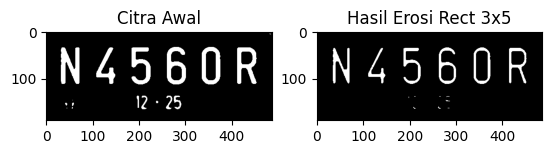

SE Rectangle 5x7


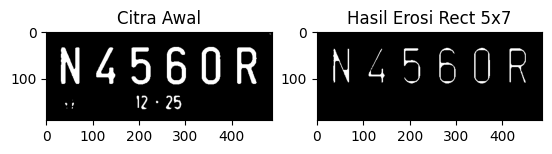

In [22]:
def erosi_rectangle(F, p, l):
    m, n = F.shape
    imgE = np.zeros((m, n), dtype=np.uint8)
    SE = cv2.getStructuringElement(cv2.MORPH_RECT, (p, l))
    constant1 = (l - 1) // 2
    constant2 = (p - 1) // 2
    for i in range(constant1, m - constant1):
        for j in range(constant2, n - constant2):
            temp = F[i - constant1:i + constant1 + 1, j - constant2:j + constant2 + 1]
            product = temp * SE
            imgE[i, j] = np.min(product)
    return imgE

img_e = cv2.imread('/content/drive/MyDrive/images/platNomor.png', 0)
ret1, thresh1 = cv2.threshold(img_e, 127, 225, cv2.THRESH_BINARY)

# Rectangle 3x5
print('SE Rectangle 3x5')
imgE_rect1 = erosi_rectangle(thresh1, 5, 3) # p=5, l=3
plt.subplot(121), plt.imshow(thresh1, cmap='gray'), plt.title('Citra Awal')
plt.subplot(122), plt.imshow(imgE_rect1, cmap='gray'), plt.title('Hasil Erosi Rect 3x5')
plt.show()

# Rectangle 5x7
print('SE Rectangle 5x7')
imgE_rect2 = erosi_rectangle(thresh1, 7, 5) # p=7, l=5
plt.subplot(121), plt.imshow(thresh1, cmap='gray'), plt.title('Citra Awal')
plt.subplot(122), plt.imshow(imgE_rect2, cmap='gray'), plt.title('Hasil Erosi Rect 5x7')
plt.show()

# Erosi dengan SE Line Vertikal 3 dan 5

SE Line Vertikal 3


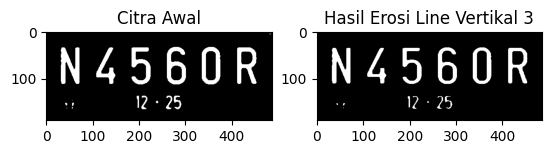

SE Line Vertikal 5


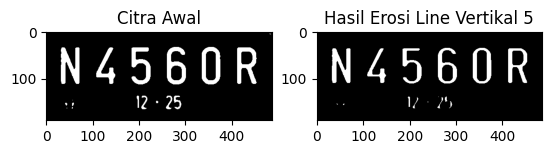

In [25]:
def erosi_line_vertical(F, k):
    m, n = F.shape
    imgE = np.zeros((m, n), dtype=np.uint8)
    SE = cv2.getStructuringElement(cv2.MORPH_RECT, (1, k)) # Lebar 1, tinggi k
    constant = (k - 1) // 2
    for i in range(constant, m - constant):
        for j in range(0, n): # Loop j disesuaikan untuk line
            temp = F[i - constant:i + constant + 1, j:j+1]
            product = temp * SE
            imgE[i, j] = np.min(product)
    return imgE

# Ganti 'platnomer.jpg' dengan 'j.png' jika Anda memilikinya
img_j = cv2.imread('/content/drive/MyDrive/images/platNomor.png', 0)
ret_j, thresh_j = cv2.threshold(img_j, 127, 225, cv2.THRESH_BINARY)

# Line Vertikal 3
print('SE Line Vertikal 3')
imgE_line3 = erosi_line_vertical(thresh_j, 3)
plt.subplot(121), plt.imshow(thresh_j, cmap='gray'), plt.title('Citra Awal')
plt.subplot(122), plt.imshow(imgE_line3, cmap='gray'), plt.title('Hasil Erosi Line Vertikal 3')
plt.show()

# Line Vertikal 5
print('SE Line Vertikal 5')
imgE_line5 = erosi_line_vertical(thresh_j, 5)
plt.subplot(121), plt.imshow(thresh_j, cmap='gray'), plt.title('Citra Awal')
plt.subplot(122), plt.imshow(imgE_line5, cmap='gray'), plt.title('Hasil Erosi Line Vertikal 5')
plt.show()

# Top-Hat Transform

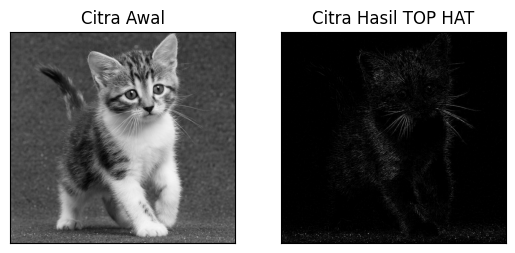

In [28]:
# Load gambar
input_image = cv2.imread('/content/drive/MyDrive/images/kitten01.jpg')
input_image = cv2.cvtColor(input_image, cv2.COLOR_BGR2GRAY)

# Kernel
filterSize = (3, 3)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, filterSize)

# Operasi Top-Hat
tophat_img = cv2.morphologyEx(input_image, cv2.MORPH_TOPHAT, kernel)

# Tampilkan hasil
plt.subplot(121), plt.imshow(input_image, cmap='gray'), plt.title('Citra Awal')
plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(tophat_img, cmap='gray'), plt.title('Citra Hasil TOP HAT')
plt.xticks([]), plt.yticks([])
plt.show()

# Black-Hat Transform


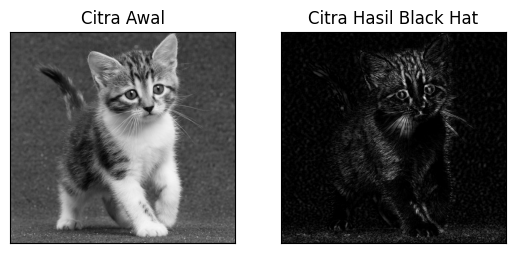

In [29]:
# Load gambar
img = cv2.imread('/content/drive/MyDrive/images/kitten01.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Kernel
Kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (13, 5))

# Operasi Black-Hat
blackhat = cv2.morphologyEx(img, cv2.MORPH_BLACKHAT, Kernel)

# Tampilkan hasil
plt.subplot(121), plt.imshow(img, cmap='gray'), plt.title('Citra Awal')
plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(blackhat, cmap='gray'), plt.title('Citra Hasil Black Hat')
plt.xticks([]), plt.yticks([])
plt.show()

# Skeletonize

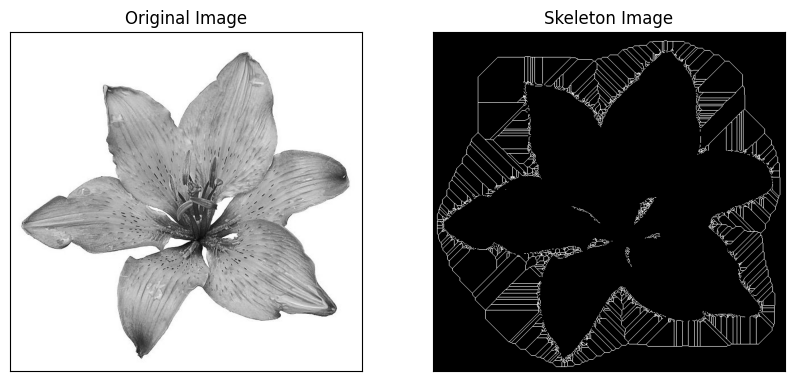

In [30]:
from skimage import filters
from skimage.morphology import skeletonize

# Load gambar
img = cv2.imread('/content/drive/MyDrive/images/lily.jpg', 0)

# Thresholding
binary_img = img > filters.threshold_triangle(img)

# Konversi boolean ke 0 dan 1
binary_cp = binary_img.copy()
binary_cp[binary_cp == True] = 1
binary_cp[binary_cp == False] = 0

# Skeletonize
skeleton = skeletonize(binary_cp)

# Tampilkan hasil
plt.figure(figsize=(10, 5))
plt.subplot(121), plt.imshow(img, cmap='gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(skeleton, cmap='gray')
plt.title('Skeleton Image'), plt.xticks([]), plt.yticks([])
plt.show()

# Skeleton Inverse

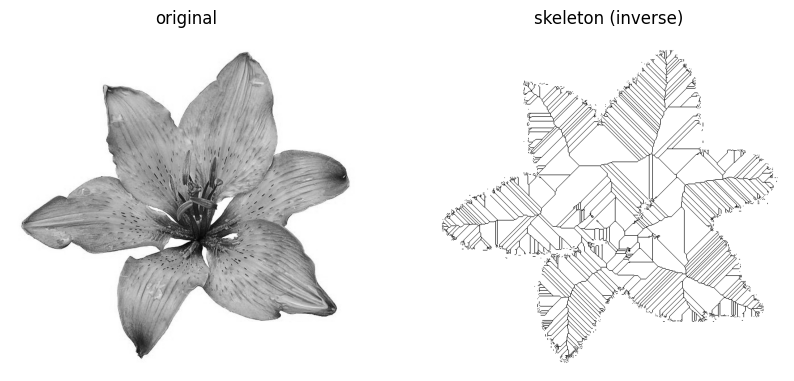

In [4]:
from skimage import io
from skimage import filters
from skimage.morphology import skeletonize

# Load gambar
img = io.imread('/content/drive/MyDrive/images/lily.jpg', as_gray=True)

# Thresholding (inverse, objek hitam jadi True)
binary = img < filters.threshold_triangle(img)

# Skeletonize
skeleton = skeletonize(binary)

# Tampilkan hasil
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img, cmap='gray')
ax[0].set_title('original')
ax[0].axis('off')
ax[1].imshow(skeleton, cmap='gray_r') # Colormap dibalik
ax[1].set_title('skeleton (inverse)')
ax[1].axis('off')
plt.show()

# Thickening (Thinning)

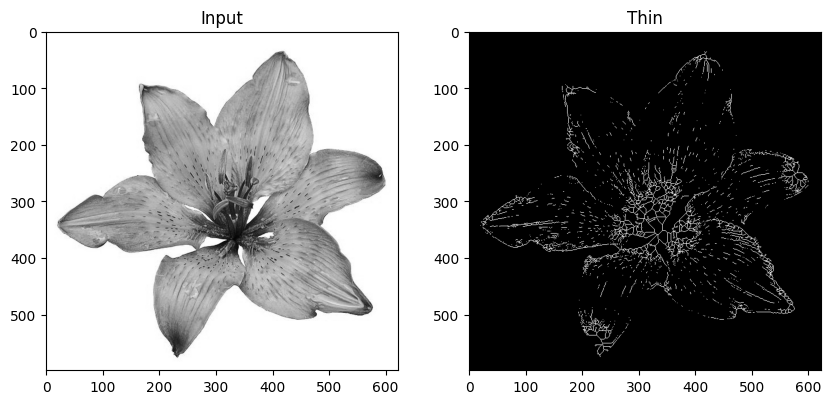

In [5]:
from skimage import io, color, morphology
from skimage.util import img_as_float

# Load gambar
image = img_as_float(io.imread('/content/drive/MyDrive/images/lily.jpg', as_gray=True))

# Binarisasi
image_binary = image < 0.5

# Thinning
out_thin = morphology.thin(image_binary)

# Tampilkan hasil
f, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 5))
ax0.imshow(image, cmap='gray')
ax0.set_title('Input')
ax1.imshow(out_thin, cmap='gray')
ax1.set_title('Thin')
plt.show()